####**1. Dataset Selection**

* Choose a real-world dataset from online sources.
* Add the dataset to your repository for submission.
* Provide a brief problem statement (What is your team trying to investigate?

The chosen dataset was taken from kaggle with the link https://www.kaggle.com/code/alsayedhamdy/philippines-dengue-cases-data-analysis-and-eda/notebook?select=ph_dengue_cases2016-2020.csv. The author Al-Sayed Hamdy credits the Department of Health for this data. The dataset contains the monthly and regional cases of dengue in the Philippines from 2016 up to 2020. Specifically it contains the 5 variables: month, year, region, dengue cases, and dengue deaths.


This project will investigate the behavior of monthly cases of dengue across the Philippines from 2016 to 2020. Through the use of resampling and simulation methods it seeks to evaluate dengue's historical patterns. Specifically, this analysis aims to:


1. To determine how stable and unbiased is the sample mean of the dengue cases dataset, and how bootstrap and jackknife resampling methods compare to theoretical estimates.
2. How accurately can a linear model predict death from dengue based on dengue cases, and how consistent is its predictive power across bootstrap resampling?
3. Did dengue cases increase significantly in 2019 compared to 2018, in line with the 2019 national dengue epidemic?
4. What is the posterior estimate of nation dengue case fatality rate computed through Bayesian inference using MCMC, and what is its 95% credible interval?
5. How well does probability density estimation show the distribution of monthly dengue cases, and is it able to represent a spike in dengue cases?


In [ ]:
library(ggplot2)
data <- read.csv("/content/ph_dengue_cases2016-2020.csv")

####**2. Bootstrap & Jackknife**

* Implement both Bootstrap and Jackknife to estimate the bias and variance of at least one statistic from the dataset (e.g., the mean, median, regression coefficient).

* Visualize the distribution of estimates.

* Compare results with theoretical estimates (if applicable)

In [ ]:
library(boot)
library(MASS)

In [ ]:
theta.hat <- mean(data$Dengue_Cases)

cat("Sample Mean =", theta.hat, "\n")

Sample Mean = 1124.926 



ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = data, statistic = mean.boot, R = 2000)


Bootstrap Statistics :
    original    bias    std. error
t1* 1124.926 -1.652959    50.68167

Bootstrap Bias: -1.652959 

Bootstrap Variance: 2568.632 


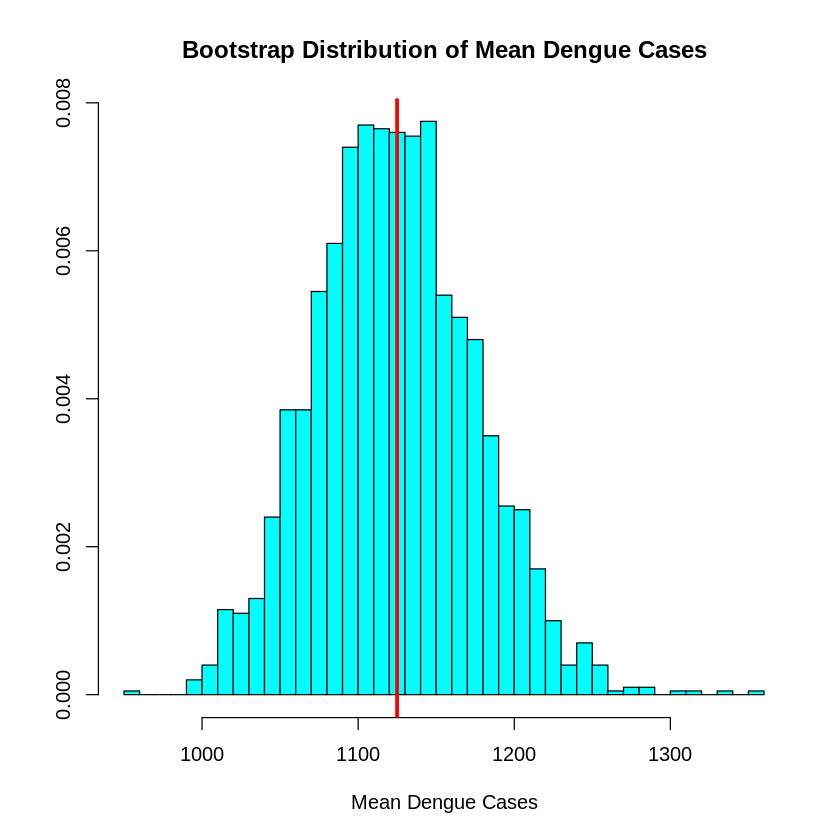

In [ ]:
# boostrap

mean.boot <- function(data, ind) {
  cases <- data$Dengue_Cases[ind]
  c(mean(cases))
}

boot.out <- boot(
  data,
  statistic = mean.boot,
  R = 2000
)

print(boot.out)

# using bootstrap to estimate bias and variance

boot.bias <- mean(boot.out$t) - boot.out$t0
boot.var <- var(boot.out$t)

cat("\nBootstrap Bias:", boot.bias, "\n")
cat("\nBootstrap Variance:", boot.var, "\n")

# histogram of distribution of estimates

MASS::truehist(
  boot.out$t,
  prob = TRUE,
  main = "Bootstrap Distribution of Mean Dengue Cases",
  xlab = "Mean Dengue Cases"
)

abline(v = boot.out$t0,
       col = "red",
       lwd = 3)

In [ ]:
# jacckknife

n <- nrow(data)

theta.jack <- numeric(n)

for (i in 1:n) {
  theta.jack[i] <- mean(data$Dengue_Cases[-i])
}

# uisng jackknife to estimate bias and variance

jack.bias <- (n-1) * (mean(theta.jack) - theta.hat)
jack.var <- (n-1) * mean((theta.jack - mean(theta.jack))^2)

cat("\nJackknife Bias:", jack.bias, "\n")
cat("\nJacknife Variance:", jack.var, "\n")



Jackknife Bias: 0 

Jacknife Variance: 2710.067 


In [ ]:
# theoretical values
sample.var <- var(data$Dengue_Cases)

theoretical.var <- sample.var / nrow(data)

# comparison
comparison <- data.frame(

  Method = c(
    "Theoretical",
    "Bootstrap",
    "Jackknife"
  ),

  Bias = c(
    0,
    boot.bias,
    jack.bias
  ),

  Variance = c(
    theoretical.var,
    boot.var,
    jack.var
  )

)

print(comparison)

       Method      Bias Variance
1 Theoretical  0.000000 2710.067
2   Bootstrap -1.652959 2568.632
3   Jackknife  0.000000 2710.067


####**3. Resampling for Model Validation**

* Apply jackknife or bootstrap resampling to assess a **predictive model** (e.g., regression, classification).
* Report performance metrics (e.g., RMSE, accuracy).
* Optionally compare different models.

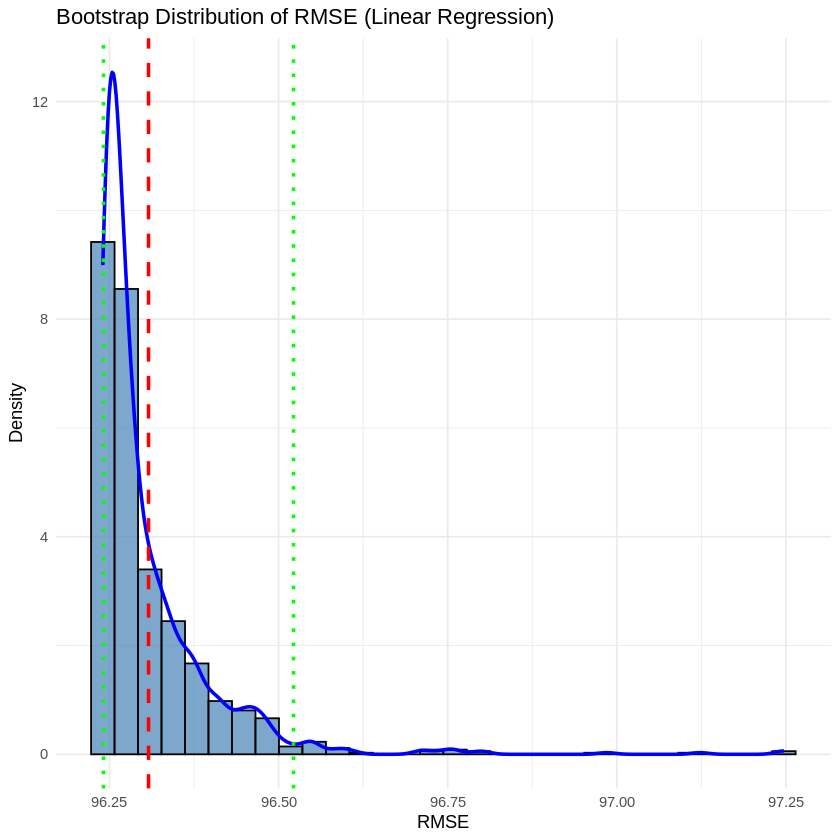

In [ ]:
n_iter <- 1000
n_size <- floor(nrow(data) * 0.8) # Train on 80% of the data
set.seed(42) # For reproducibility

rmses <- numeric(n_iter)

for (i in 1:n_iter) {
  train_indices <- sample(1:nrow(data), size = n_size, replace = TRUE)
  train_data <- data[train_indices, ]

  model <- lm(Dengue_Deaths ~ Dengue_Cases, data = train_data)
  predictions <- predict(model, newdata = data)
  mse <- mean((data$Dengue_Deaths - predictions)^2)
  rmses[i] <- sqrt(mse)
}

mean_rmse <- mean(rmses)
lower_ci <- quantile(rmses, 0.025)
upper_ci <- quantile(rmses, 0.975)

# plot
rmse_df <- data.frame(RMSE = rmses)
p1 <- ggplot(rmse_df, aes(x = RMSE)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "steelblue", color = "black", alpha = 0.7) +
  geom_density(color = "blue", linewidth = 1) +
  geom_vline(xintercept = mean_rmse, color = "red", linetype = "dashed", linewidth = 1) +
  geom_vline(xintercept = lower_ci, color = "green", linetype = "dotted", linewidth = 1) +
  geom_vline(xintercept = upper_ci, color = "green", linetype = "dotted", linewidth = 1) +
  labs(title = "Bootstrap Distribution of RMSE (Linear Regression)",
       x = "RMSE", y = "Density") +
  theme_minimal()

print(p1)

## **4. Permutation Tests**


* Choose a hypothesis (e.g., group mean difference, independence between variables).
* Apply a permutation test to test this hypothesis.
* Include null distribution plots, p-values, and interpret results.




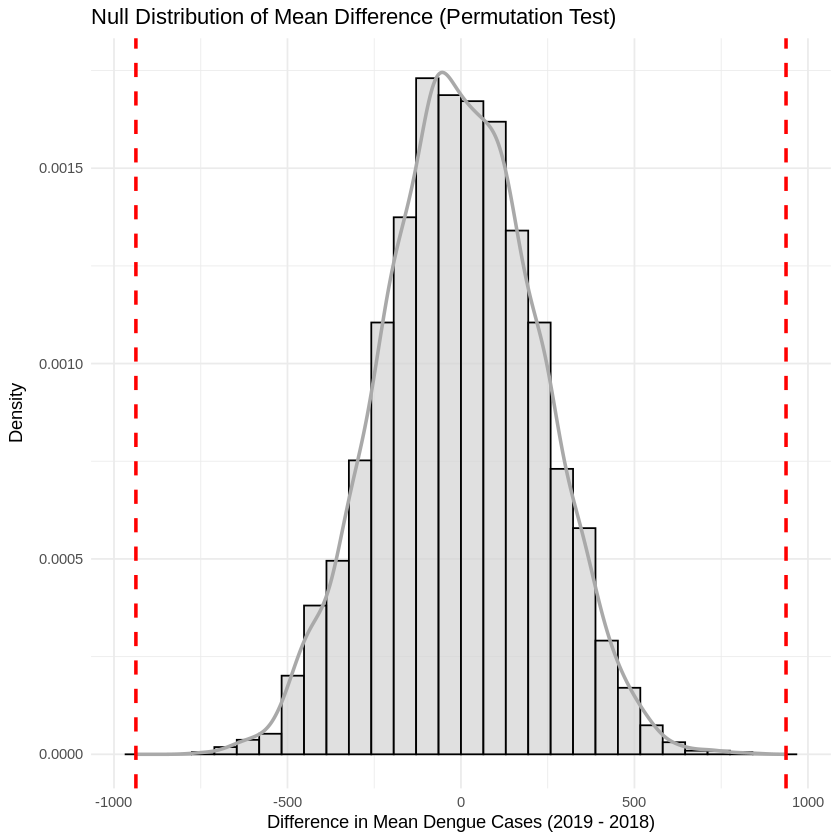

In [ ]:
data_2018 <- data$Dengue_Cases[data$Year == 2018]
data_2019 <- data$Dengue_Cases[data$Year == 2019]
obs_diff <- mean(data_2019) - mean(data_2018)

combined_data <- c(data_2018, data_2019)
n_2018 <- length(data_2018)
n_permutations <- 5000
perm_diffs <- numeric(n_permutations)

for (i in 1:n_permutations) {
  shuffled_data <- sample(combined_data)
  pseudo_2018 <- shuffled_data[1:n_2018]
  pseudo_2019 <- shuffled_data[(n_2018 + 1):length(shuffled_data)]
  perm_diffs[i] <- mean(pseudo_2019) - mean(pseudo_2018)
}

# p-value
p_value <- sum(abs(perm_diffs) >= abs(obs_diff)) / n_permutations

# plot
perm_df <- data.frame(Difference = perm_diffs)
p2 <- ggplot(perm_df, aes(x = Difference)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "lightgray", color = "black", alpha = 0.7) +
  geom_density(color = "darkgray", linewidth = 1) +
  geom_vline(xintercept = obs_diff, color = "red", linetype = "dashed", linewidth = 1) +
  geom_vline(xintercept = -obs_diff, color = "red", linetype = "dashed", linewidth = 1) +
  labs(title = "Null Distribution of Mean Difference (Permutation Test)",
       x = "Difference in Mean Dengue Cases (2019 - 2018)", y = "Density") +
  theme_minimal()

print(p2)

In [ ]:
cat(sprintf("Bootstrap Mean RMSE: %.4f\n", mean_rmse))
cat(sprintf("Bootstrap RMSE 95%% CI: (%.4f, %.4f)\n", lower_ci, upper_ci))
cat(sprintf("\nObserved Mean Difference (2019-2018): %.4f\n", obs_diff))
cat(sprintf("Permutation Test p-value: %.4f\n", p_value))

Bootstrap Mean RMSE: 96.3078
Bootstrap RMSE 95% CI: (96.2411, 96.5221)

Observed Mean Difference (2019-2018): 936.8578
Permutation Test p-value: 0.0000


## **5. MCMC for Bayesian Inference**

In [ ]:
library(ggplot2)
data <- read.csv("/content/ph_dengue_cases2016-2020.csv")
colnames(data)[1] <- "Month" # fixes hidden BOM character on first column name
str(data)

'data.frame':	1020 obs. of  5 variables:
 $ Month        : chr  "January" "February" "March" "April" ...
 $ Year         : int  2016 2016 2016 2016 2016 2016 2016 2016 2016 2016 ...
 $ Region       : chr  "Region I" "Region I" "Region I" "Region I" ...
 $ Dengue_Cases : int  705 374 276 240 243 345 1295 1598 1415 1000 ...
 $ Dengue_Deaths: int  1 0 0 2 1 1 2 3 3 6 ...


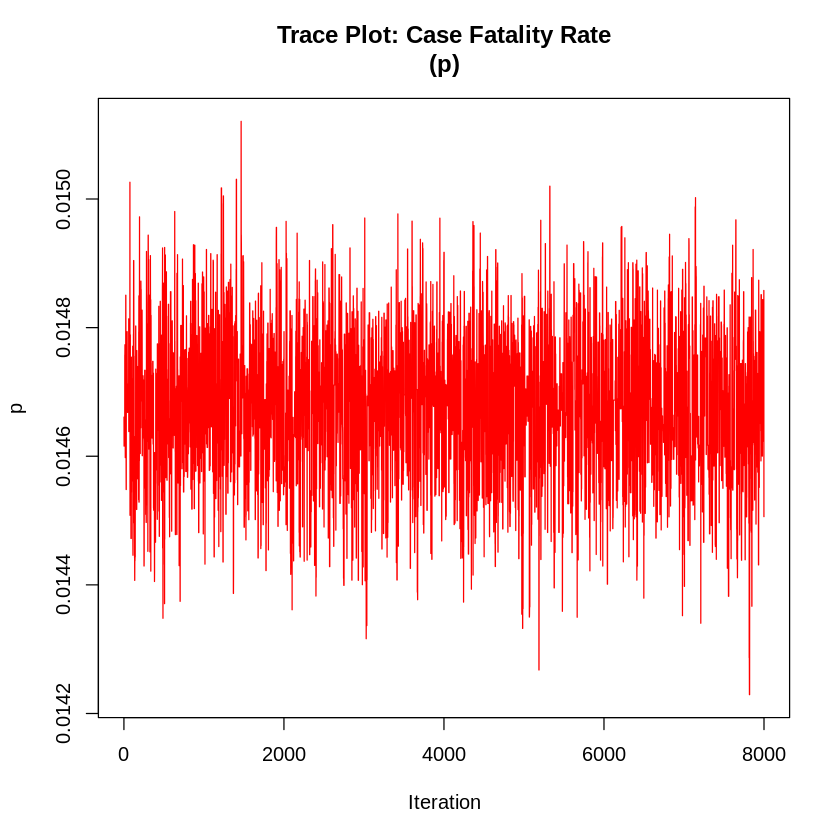

MLE fatality rate: 0.01467983 
Posterior mean: 0.01467565 
95% Credible interval: 0.01444369 0.01488939 
Acceptance rate: 0.3274 


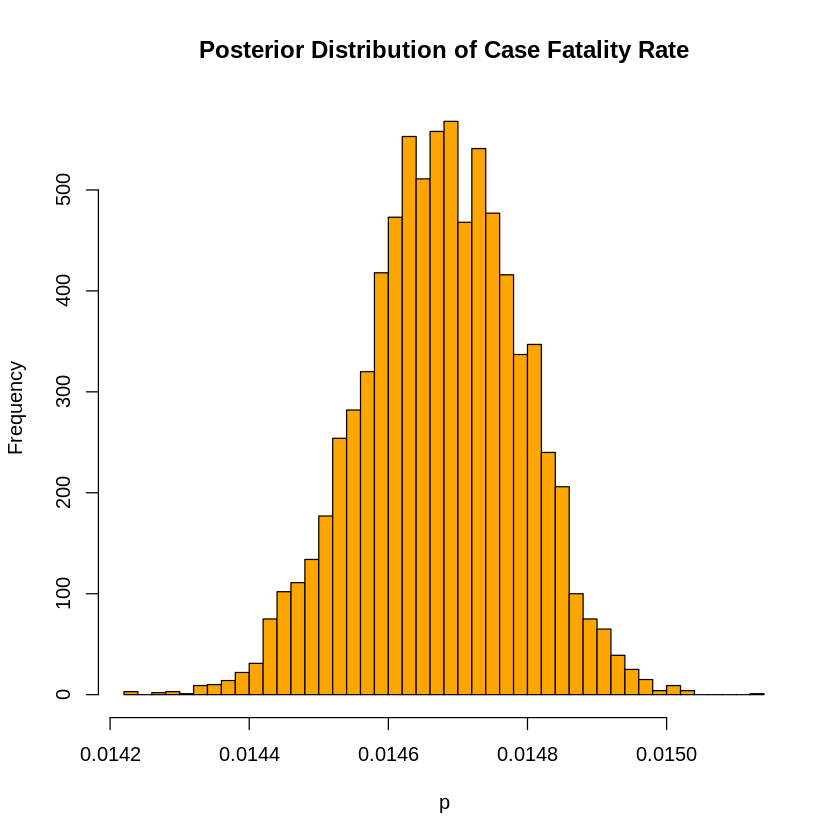

In [ ]:
set.seed(123)
total_cases <- sum(data$Dengue_Cases, na.rm = TRUE)
total_deaths <- sum(data$Dengue_Deaths, na.rm = TRUE)
log_posterior <- function(p) {
 if (p <= 0 || p >= 1) return(-Inf)
 dbinom(total_deaths, size = total_cases, prob = p, log = TRUE) +
 dunif(p, 0, 1, log = TRUE)
}

n_iter <- 10000
p_chain <- numeric(n_iter)
p_chain[1] <- total_deaths / total_cases
proposal_sd <- 0.0003
for (i in 2:n_iter) {
 p_current <- p_chain[i - 1]
 p_proposed <- p_current + rnorm(1, 0, proposal_sd)
 log_accept_ratio <- log_posterior(p_proposed) -
log_posterior(p_current)
 if (log(runif(1)) < log_accept_ratio) {
 p_chain[i] <- p_proposed
 } else {
 p_chain[i] <- p_current
 }
}

burn_in <- 2000
posterior_p <- p_chain[(burn_in + 1):n_iter]
plot(posterior_p, type = "l", main = "Trace Plot: Case Fatality Rate
(p)",
 xlab = "Iteration", ylab = "p", col = "Red")
hist(posterior_p, breaks = 40, col = "orange",
 main = "Posterior Distribution of Case Fatality Rate",
 xlab = "p")

cat("MLE fatality rate:", total_deaths / total_cases, "\n")
cat("Posterior mean:", mean(posterior_p), "\n")
cat("95% Credible interval:", quantile(posterior_p, c(0.025, 0.975)),
"\n")
cat("Acceptance rate:", length(unique(posterior_p)) / n_iter, "\n")

## **6.** **Probability Density Estimation**

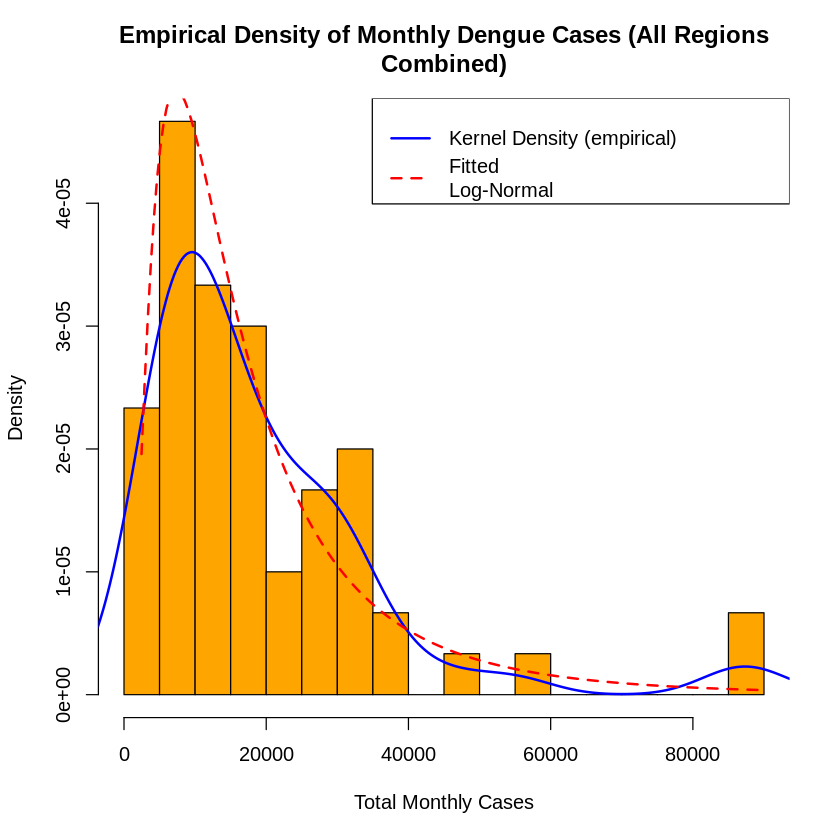

Log-normal fit parameters:
  meanlog     sdlog 
9.5416936 0.8023438 


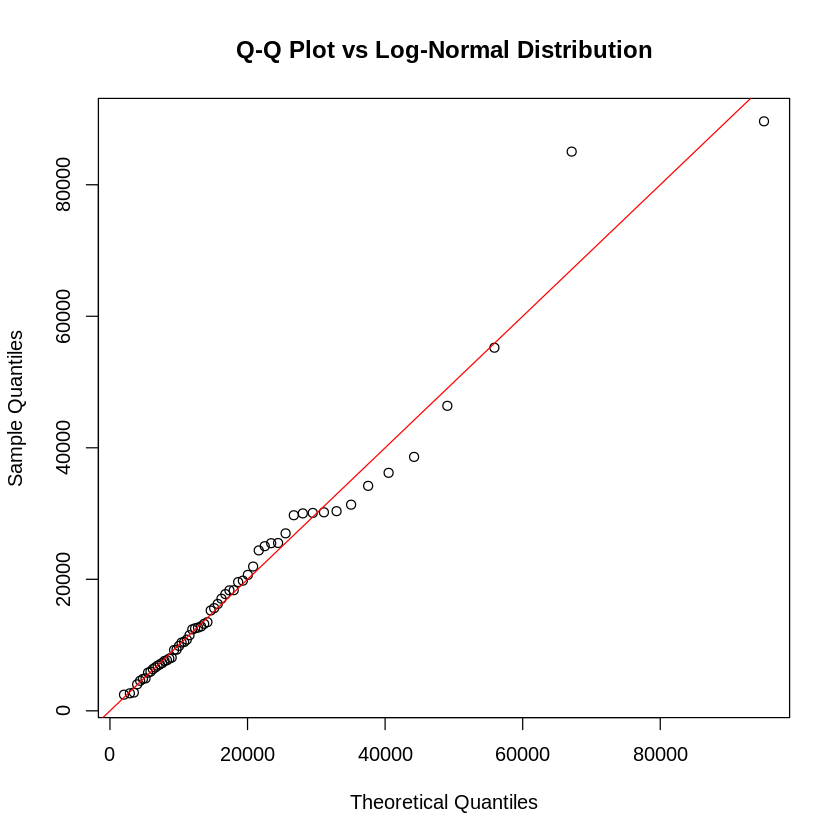

In [ ]:
library(MASS)

data$time_index <- as.numeric(factor(paste(data$Year, data$Month),
 levels = unique(paste(data$Year,
data$Month))))
monthly_totals <- aggregate(Dengue_Cases ~ time_index, data = data,
sum)$Dengue_Cases
hist(monthly_totals, breaks = 20, freq = FALSE, col = "Orange",
 main = "Empirical Density of Monthly Dengue Cases (All Regions
Combined)",
 xlab = "Total Monthly Cases")
lines(density(monthly_totals), col = "blue", lwd = 2)
fit <- fitdistr(monthly_totals, "lognormal")
x_vals <- seq(min(monthly_totals), max(monthly_totals), length.out =
200)
lognorm_density <- dlnorm(x_vals, meanlog = fit$estimate["meanlog"],
sdlog = fit$estimate["sdlog"])
lines(x_vals, lognorm_density, col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("Kernel Density (empirical)", "Fitted
Log-Normal"), col = c("blue", "red"), lty = c(1, 2), lwd = 2)

qqplot(qlnorm(ppoints(length(monthly_totals)),
fit$estimate["meanlog"], fit$estimate["sdlog"]),
 monthly_totals, main = "Q-Q Plot vs Log-Normal Distribution",
 xlab = "Theoretical Quantiles", ylab = "Sample Quantiles")
abline(0, 1, col = "red")

cat("Log-normal fit parameters:\n")
print(fit$estimate)

####**7. Summary (Team Task)**


**Summarize all findings.**


The sample mean for dengue cases was 1124.926, this means that from 2016-2020 there were approximately 1125 dengue cases across the Philippines every month. This also serves as the basis for both the bootstrap and jackknife code.


The bootstrap bias was estimated to be approximately -1.65 and its variance was approximately 2568.63, with a bell-shaped histogram of estimates that is centered near the sample mean. Further, jackknife bias was 0 and its variance was 2710.068. The theoretical variances were also computed to be 2710.068. Since both methods produce a low bias along with a small variance near or same as theoretical variance, this confirms that sample mean is a reliable and stable estimator of average monthly dengue cases.


For the Bayesian analysis, our MCMC estimated the national dengue case fatality rate at 1.47% (95% CI: 1.44% - 1.49%) using Metropolis Hastings, with strong chain mixing and a healthy 32.7% acceptance rate confirming reliable convergence. Our density estimation further showed that monthly case counts are strongly right-skewed, with a log-normal distribution capturing typical seasonal patterns well but understanding a handful of extreme outbreak months most plausibly tied to the 2019 national dengue epidemic.


The distribution of total monthly dengue cases across all regions is strongly right-skewed, with most months clustering between 5,000-20,000 cases and a long tail extending toward 90,000 in outbreak periods. A log-normal distribution (meanlog = 9.54, sdlog = 0.80) captured the general shape of this distribution reasonably well, particularly through the bulk of typical months. However, the Q-Q plot revealed a clear divergence at the upper tail — a handful of months with extreme case counts sat well above what the log-normal model predicted. This points to a small number of severe outbreak periods (most plausibly aligning with the 2019 national dengue epidemic) that behave differently from typical seasonal fluctuation.


A permutation test comparing the two years yielded an observed mean increase of 936.8578 cases in 2019, with a p-value of 0.0000. To evaluate our predictive capabilities, we tested a linear regression model using bootstrap resampling, which resulted in a Bootstrap Mean Root Mean Square Error (RMSE) of 96.3078 and a narrow 95% Confidence Interval of (96.2411, 96.5221). However, the bootstrap distribution of the RMSE is noticeably right-skewed. This indicates that while the average prediction error is around 96 cases, the model occasionally produces much higher errors, likely when it struggles to capture extreme spikes during the outbreak.


**Write a conclusion to your problem statement.**


This project aimed to examine the behavior, reliability, and predictability of monthly cases of dengue across the Philippines from 2016 to 2020, through the use of sampling and simulation methods in R. Overall, the results showed that while sample mean is a stable and unbiased measure of average monthly daily cases, this can mainly be attributed to extreme outbreak cases, instead of consistent patterns.


The bootstrap and jackknife analysis performed were able to validate sample mean of 1,125 dengue cases as a reliable estimator. Both methods produced negligible bias and variance close to theoretical estimate, with jackknife having a variance equal to theoretical estimate. Additionally, the bootstrap validation model showed that a linear model that predicts dengue deaths based on dengue cases, managed to generate a consistent prediction error, shown by the calculated mean RMSE of approximately 96.3 and a narrow 95% confidence interval. However, the right skewed RMSE distribution indicates that this linear model struggles to predict dengue death when there is an outbreak of dengue cases. In line with this, the permutation test provided strong statistical evidence of a significant increase of dengue cases from 2018 to 2019, which aligns the 2019 Philippine dengue epidemic.


The Bayesian interference using Metropolis-Hastings MCMC estimated that the national dengue case fatality rate is approximately 1.47%, with a  95% credible interval  of 1.44% to 1.49%, which indicates that the posterior estimate was precise under the assumption that the fatality rate is constant throughout the 2016 to 2020. Finally, the probability density estimate revealed that dengue case totals are strongly right-skewed, which can possibly be attributed to the mentioned 2019 dengue epidemic. The use of a log-normal distribution managed to represent the majority of the observations, although the Q-Q plot failed to account for the extreme upper tail of more than 80,000 dengue cases.




Overall, this project managed to highlight the importance of combining statistical methods in order to accurately show distribution of dengue cases, uncertain predictive performance of a linear model for dengue deaths, and patterns found in monthly dengue cases from 2016 to 2020.


**Discuss limitations, surprises, and future exploration ideas.**


The project is limited by only having data from 2016-2020, and additionally it does not have other variables such as rainfall or temperature, which may also affect the number of dengue cases. Our suggestion for future exploration is that researchers use a longer and more recent dataset, and try to join it with a dataset containing relevant weather variables.


TASK 2 LIMITATIONS:
* The analysis simply focused on the mean, and it did not include other statistic such as median  or regression coefficient which may have other sampling distributions
* Both jackknife and bootstrap assume that the dataset is representative of the population. There is a possibility that there are inconsistencies in the dataset which weren't accounted for.


TASK 2 SURPRISES:
* The jackknife bias was 0 and its variance was equal to the theoretical variance. This confirmed that the sample mean is unbiased and that the jackknife is well suited for this particular dataset.


TASK 2 FUTURE EXPLORATION IDEAS:
* Use other statistics such as median or regression coefficient, and compare their performance with mean
* See how number of bootstrap resamples may affect bootstrap bias and variance
* Use a different dengue case with more or less samples to see how sample size can affect performance


TASK 3 AND 4 LIMITATIONS:
*  Standard linear regression relies on assumptions that oversimplify epidemiological data, which typically follows exponential or cyclical seasonal patterns rather than linear trends.
*  The model is highly susceptible to massive outliers, such as those recorded during the severe 2019 outbreak year.  


TASK 3 AND 4 SURPRISES:
*  The permutation test resulted in an absolutely certain p-value of exactly 0.0000. This emphasizes just how extreme the 2019 surge was when compared to the null distribution.
*  It was unexpected to observe such a narrow confidence interval for the Root Mean Square Error (RMSE) given the visible skew in its distribution.


TASK 3 AND 4 FUTURE EXPLORATION IDEAS:
* The team should transition to models specifically built for count data and non-linear trends, such as Poisson regression, Negative Binomial regression, or ARIMA time-series forecasting.
* Integrating factors like rainfall, humidity, and temperature could significantly enhance the model's predictive power.
*  Shifting the focus from yearly aggregates to more granular monthly or weekly data would help identify the exact seasonal triggers of these outbreaks.




TASK 5 AND 6 LIMITATIONS:
* The dataset contained 18 rows where reported deaths exceeded reported cases, indicating data entry or compilation errors, concentrated mostly around September–October across a few specific years and regions. This limits full confidence in the precision of fatality estimates for those affected periods.


* The analysis aggregated data at a national or regional-monthly level, which may mask finer-grained patterns (e.g., specific provinces or weekly trends) that could be relevant for localized outbreak response.
Our MCMC model assumed a constant fatality rate across the entire 2016–2020 period, but the rate may have shifted year to year (e.g., due to changes in reporting, healthcare access, or treatment protocols), which a static binomial model can't capture.


* The log-normal distribution, while a reasonable approximation, is a relatively simple model and doesn't fully capture the heavy-tailed nature of outbreak months.


TASK 5 AND 6 SURPRISES:
* The clear mismatch between the log-normal fit and the extreme outbreak months was a genuinely useful finding, it wasn't just a modeling imperfection, but a meaningful signal pointing to real, distinct epidemic behavior (likely the 2019 outbreak) that a "typical seasonal" model simply doesn't account for.


* The data quality issue (deaths exceeding cases) was unexpected and required us to make judgment calls about cleaning, a good reminder that real-world datasets, even from official-seeming sources, often need careful scrutiny before analysis.


TASK 5 AND 6 FUTURE EXPLORATION IDEAS:
* Incorporate climate variables (rainfall, temperature, humidity) as predictors, since dengue transmission is strongly linked to mosquito breeding conditions, this could help explain why certain months spike.


* Break the analysis down by region to identify whether some areas are more prone to outbreak-level surges than others, which would have direct value for targeted public health resource allocation.